#Libraries

In [2]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#PHASE 7 - SHAP EXPLAINABILITY



In [3]:
#SHAP (SHapley Additive exPlanations) is used to interpret machine learning models by measuring the contribution of each feature to a prediction.

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import joblib

rf_under = joblib.load(
    "/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/final_rf_under.pkl"
)

print("Random Forest Model Loaded")

Random Forest Model Loaded


In [6]:
base_path = "/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/"

X_test = pd.read_csv(
    base_path + "X_test_scaled.csv"
)

y_test = pd.read_csv(
    base_path + "y_test.csv"
).squeeze()

print("Test Shape:", X_test.shape)

Test Shape: (18891, 20)


##SHAP Explainer

In [7]:
explainer = shap.TreeExplainer(
    rf_under
)

print("SHAP Explainer Created")

SHAP Explainer Created


##Create Sample Data

In [10]:
X_test_sample = X_test.sample(
    n=1000,
    random_state=42
)

print("Sample Shape:", X_test_sample.shape)

Sample Shape: (1000, 20)


In [11]:
shap_values = explainer.shap_values(
    X_test_sample
)

# Handle different SHAP versions

if isinstance(shap_values, list):

    shap_vals = shap_values[1]

else:

    shap_vals = shap_values

print("SHAP Values Computed")
print("Shape:", shap_vals.shape)

SHAP Values Computed
Shape: (1000, 20, 2)


In [14]:
# For binary classification
# Use SHAP values for class 1 (dissatisfied)

shap_vals_class1 = shap_vals[:, :, 1]

print(shap_vals_class1.shape)

(1000, 20)


## SHAP Feature Importance

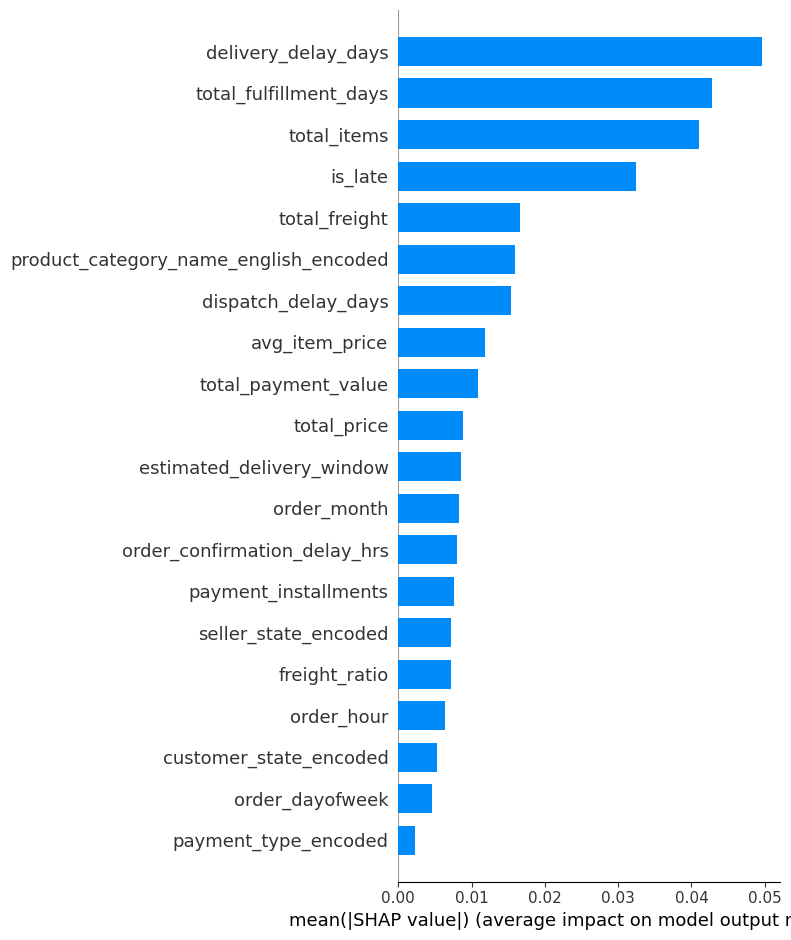

In [16]:
shap.summary_plot(
    shap_vals_class1,
    X_test_sample,
    plot_type='bar'
)

In [22]:
#Delivery-related variables such as:

#- delivery_delay_days
#- dispatch_delay_days
#- total_fulfillment_days

#have the highest impact on dissatisfaction prediction.

#This confirms that delivery performance is a major driver of customer experience in e-commerce.

#Transaction-related features such as payment installments
#and total items also contribute to dissatisfaction, though to a lesser extent.

##SHAP Summary Plot

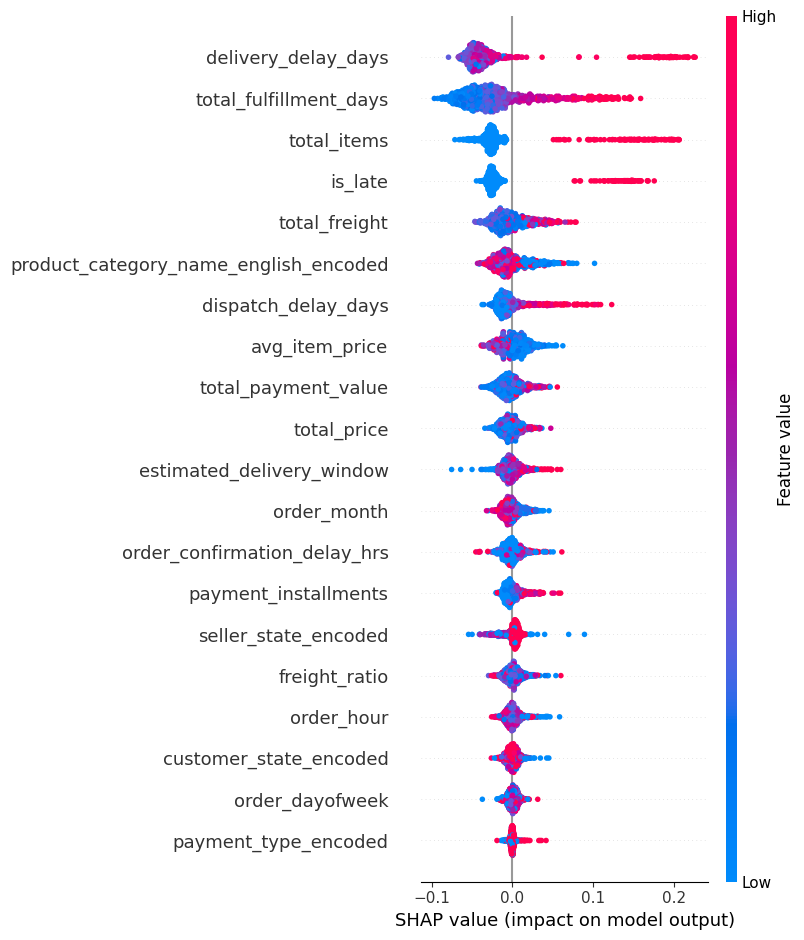

In [17]:
shap.summary_plot(
    shap_vals_class1,
    X_test_sample
)

In [18]:
#Each dot represents one customer/order

#Red dots indicate high feature values

#Blue dots indicate low feature values

#Positive SHAP values push predictions toward DISSATISFIED

#Negative SHAP values push predictions toward SATISFIED

##Feature Importance Table

In [19]:
shap_importance = np.abs(
    shap_vals_class1
).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'SHAP Importance': shap_importance
})

shap_df = shap_df.sort_values(
    by='SHAP Importance',
    ascending=False
)

print(shap_df.head(10))

                                  Feature  SHAP Importance
13                    delivery_delay_days         0.049605
14                 total_fulfillment_days         0.042859
2                             total_items         0.041069
15                                is_late         0.032470
1                           total_freight         0.016629
18  product_category_name_english_encoded         0.015895
12                    dispatch_delay_days         0.015309
6                          avg_item_price         0.011806
3                     total_payment_value         0.010848
0                             total_price         0.008812


In [20]:
shap_df.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/SHAP/shap_feature_importance.csv',
    index=False
)

print("SHAP Feature Importance Saved")

SHAP Feature Importance Saved


##waterfall plot

In [26]:
#The waterfall plot explains one individual prediction.

In [24]:
# Predict probabilities

y_prob = rf_under.predict_proba(
    X_test_sample
)[:, 1]

# Apply deployed threshold

y_pred = (
    y_prob >= 0.35
).astype(int)

# Select first customer

idx = 0

print("Customer Index:", idx)
print("Predicted Probability:", round(y_prob[idx], 4))
print("Predicted Class:", y_pred[idx])

Customer Index: 0
Predicted Probability: 0.41
Predicted Class: 1


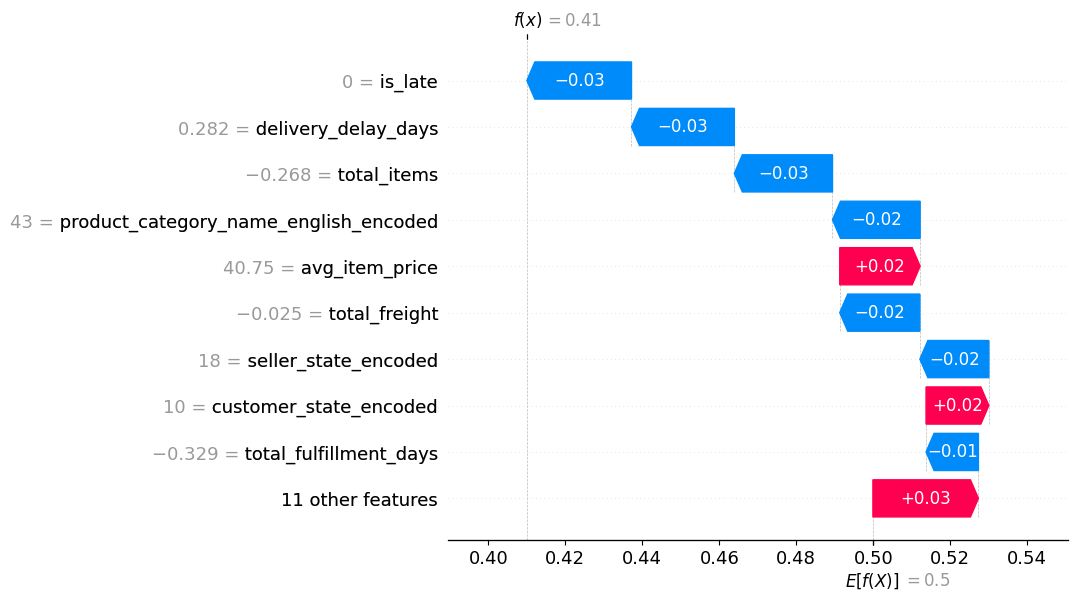

In [25]:
base_value = explainer.expected_value

# Handle different SHAP versions

if isinstance(base_value, np.ndarray):
    base_value = base_value[1]

shap.plots.waterfall(

    shap.Explanation(

        values=shap_vals_class1[idx],

        base_values=base_value,

        data=X_test_sample.iloc[idx],

        feature_names=X_test_sample.columns

    )

)

In [ ]:
# This provides local explainability by showing why a specific customer was predicted as
# satisfied or dissatisfied.

#BUSINESS INSIGHTS

In [27]:
print("""

BUSINESS INSIGHTS

1. Delivery-related variables consistently rank among
   the most important features in SHAP analysis.

2. delivery_delay_days and total_fulfillment_days
   have the strongest impact on dissatisfaction.

3. Customers experiencing longer delivery times are
   significantly more likely to leave negative reviews.

4. Transaction-related features such as total_items,
   total_freight and payment behaviour also influence
   customer satisfaction.

5. SHAP results validate findings from EDA,
   feature engineering and model evaluation.

""")



BUSINESS INSIGHTS

1. Delivery-related variables consistently rank among
   the most important features in SHAP analysis.

2. delivery_delay_days and total_fulfillment_days
   have the strongest impact on dissatisfaction.

3. Customers experiencing longer delivery times are
   significantly more likely to leave negative reviews.

4. Transaction-related features such as total_items,
   total_freight and payment behaviour also influence
   customer satisfaction.

5. SHAP results validate findings from EDA,
   feature engineering and model evaluation.


